### Desde acá, hago ajustes con MENOS picos, ya que algunos se hicieron cero

In [ ]:
# %% ------ Elegir ciclos ------------------------------------------------------------

ciclo_retomar = 300
ciclo_final = 600


excluir = {30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247} # ciclos feos
ciclos_seleccionados_2 = [c for c in ciclos_disponibles if ciclo_retomar <= c <= ciclo_final and c not in excluir]

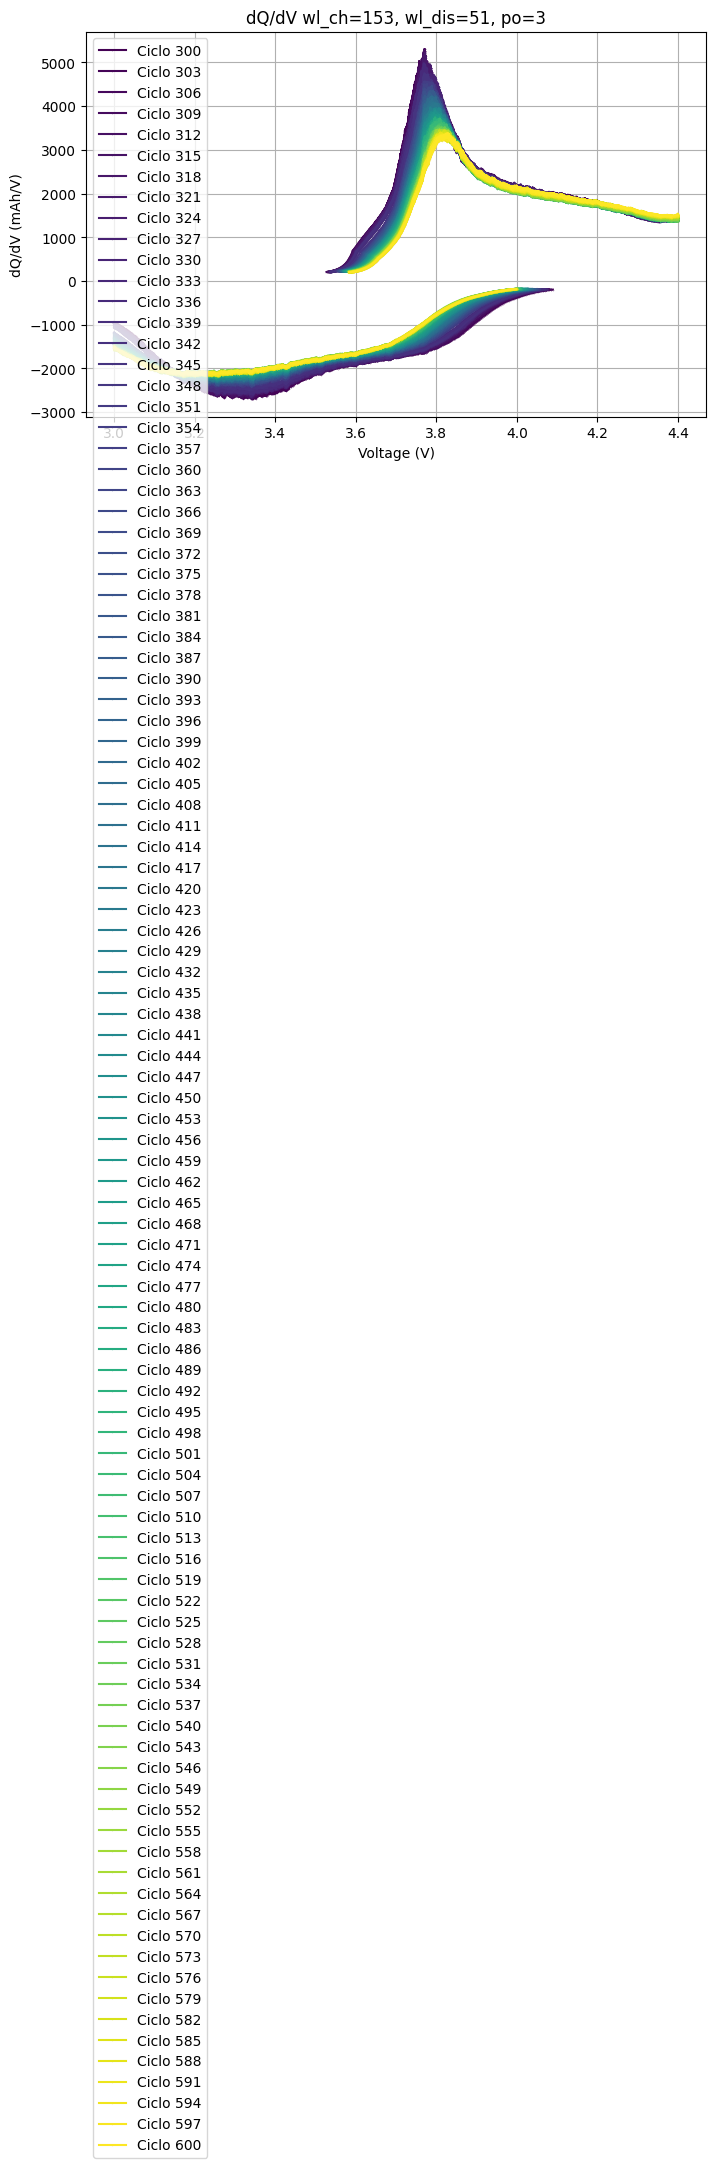

In [ ]:
# %% ------- Trunco datos y calculo derivada ------------------------------------------------------------
diccio_2 = func_deriv.truncar_señal(ciclos_seleccionados, dict_ciclos_sep)
diccio_2 =  func_deriv.plot_dqdv(ciclos_seleccionados, diccio_2)

In [ ]:
parametros = df_final.loc[ciclo_retomar].values

p_ini_2 = [parametros[i:i+3] for i in range(0, n_peaks*3, 3)]

# Quito pico 1
p_ini_2.pop(0)
print(p_ini_2)

[array([4.24225194e+02, 3.74000000e+00, 3.22681344e-02]), array([2.73103204e+03, 3.77733223e+00, 5.12969725e-02]), array([2.25623923e+03, 3.95000000e+00, 2.46005709e-01]), array([8.86733291e+02, 4.38006496e+00, 1.41327456e-01])]


In [ ]:
ciclos = ciclos_seleccionados_2     # los que quieras ajustar
resultados = []             # lista de parámetros ajustados
covs = []                   # lista de matrices de covarianza
areas = []                  # lista de áreas de cada pico

# inicialización con p_ini
p0_actual = p_ini_2
n_peaks_2 = len(p_ini_2)//3

# Realizar ajustes
for ciclo in ciclos:
    try:
        df_ch = diccio_2[ciclo]['Ch']
        V = df_ch['V_ch_savgol']
        dqdv = df_ch['dqdv_ch_calc']

        print(f'Ajustando ciclo {ciclo}...')
        # Ajuste
        popt, pcov = curve_fit(multi_gauss, V, dqdv, p0=p0_actual, bounds=bounds)
    
        # Guardar resultados
        resultados.append(popt)
        covs.append(pcov)
        
        # Calcular áreas de cada gaussiana
        areas_picos = []
        for i in range(0, len(popt), 3):
            a, mu, sigma = popt[i:i+3]
            area = a * sigma * np.sqrt(2*np.pi)
            areas_picos.append(area)
        areas.append(areas_picos)
    
        # Actualizar p0 para el siguiente ciclo
        p0_actual = popt

        # Plot
        if ciclo in ciclos_grafico:
            plt.figure()
            y_fit = multi_gauss(V, *popt)
            plt.plot(V, dqdv, label=f"Datos ciclo {ciclo}")
            plt.plot(V, y_fit, 'r-', label="Ajuste total")

            for i in range(0, len(popt), 3):
                a, mu, sigma = popt[i:i+3]
                j = i // 3   # índice de pico: 0,1,2,...
                plt.plot(V, gauss(V, a, mu, sigma), '--', color=colors[j % len(colors)], label=f"Pico {j + 1}")

            plt.legend()
            plt.xlabel("Voltaje (V)")
            plt.ylabel("dQ/dV (mAh/Vg)")
            plt.title(f"Ajuste ciclo {ciclo}")
            plt.savefig(f'./output/ajuste_picos_ciclo{ciclo}.png', dpi=300)
            plt.close()
    
    except Exception as e:
        # si falla, llenar con NaN
        resultados.append([np.nan,np.nan,np.nan] * n_peaks)
        covs.append(np.full((n_peaks*3, n_peaks*3), np.nan))  # matriz covarianza "vacía"
        areas.append([np.nan] * n_peaks)

# %% ------- Crear DataFrame con parámetros y áreas ------------------------------------------------------------
cols = []
cols_area = []

for i in range(n_peaks):
    cols += [f"a{i+1}", f"mu{i+1}", f"sigma{i+1}"]
    cols_area.append(f"area{i+1}")

df_params = pd.DataFrame(resultados, index=ciclos, columns=cols)
df_areas = pd.DataFrame(areas, index=ciclos, columns=cols_area)
df_final = pd.concat([df_params, df_areas], axis=1)

# Guardar a CSV
df_final.to_csv("./output/parametros_ajustes_segunda-etapa.csv")

print("Ajustes terminados. Resultados guardados en './output/parametros_ajustes.csv'")

Ajustando ciclo 300...
Ajustando ciclo 303...
Ajustando ciclo 306...
Ajustando ciclo 309...
Ajustando ciclo 312...
Ajustando ciclo 315...
Ajustando ciclo 318...
Ajustando ciclo 321...
Ajustando ciclo 324...
Ajustando ciclo 327...
Ajustando ciclo 330...
Ajustando ciclo 333...
Ajustando ciclo 336...
Ajustando ciclo 339...
Ajustando ciclo 342...
Ajustando ciclo 345...
Ajustando ciclo 348...
Ajustando ciclo 351...
Ajustando ciclo 354...
Ajustando ciclo 357...
Ajustando ciclo 360...
Ajustando ciclo 363...
Ajustando ciclo 366...
Ajustando ciclo 369...
Ajustando ciclo 372...
Ajustando ciclo 375...
Ajustando ciclo 378...
Ajustando ciclo 381...
Ajustando ciclo 384...
Ajustando ciclo 387...
Ajustando ciclo 390...
Ajustando ciclo 393...
Ajustando ciclo 396...
Ajustando ciclo 399...
Ajustando ciclo 402...
Ajustando ciclo 405...
Ajustando ciclo 408...
Ajustando ciclo 411...
Ajustando ciclo 414...
Ajustando ciclo 417...
Ajustando ciclo 420...
Ajustando ciclo 423...
Ajustando ciclo 426...
Ajustando c